# FASE 5: INDEKS KOMPOSIT DAN PENILAIAN RISIKO
Langkah ini menggabungkan intensitas alam (FRP), indikator ancaman infrastruktur (jarak sekolah), indeks demografi (populasi), dan pendorong temporal musiman (musim kemarau) menjadi skor komposit bahaya kebakaran yang terukur (skala 0 sampai 100).

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import os
import time

start_time = time.time()
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../outputs/figures', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

fig_dir = '../outputs/figures'
sns.set_theme(style="whitegrid")
PALETTE_RED = "#C0392B"
PALETTE_GOLD = "#F39C12"

## Pembuatan Skor Risiko Kebakaran
Setiap metrik digabungkan dengan bobot tertentu:
Kekuatan api (FRP) dinormalisasi, jarak sekolah dievaluasi (makin dekat makin berisiko),
kemudian dikalikan dengan faktor populasi wilayah dan faktor musim kemarau.

In [10]:
print("\n[5.1] Mengalkulasi model nilai skor gabungan (Composite Index)")
df_master = pd.read_csv('../data/processed/hotspot_master.csv')

frp_cap = df_master['frp'].quantile(0.99)
df_master['frp_capped'] = df_master['frp'].clip(upper=frp_cap)
frp_score = (df_master['frp_capped'] / frp_cap) * 100

dist_school = df_master['dist_nearest_school_km'].fillna(100)
df_master['exposure_score'] = np.maximum(0, 100 * (1 - (dist_school / 50)))

pop = df_master['population'].fillna(df_master['population'].mean())
min_pop = pop.min()
max_pop = pop.max()
pop_mult = 0.8 + 0.4 * ((pop - min_pop) / (max_pop - min_pop))

season_mult = df_master['is_dry_season'].apply(lambda x: 1.5 if x else 1.0)

base_score = (0.6 * frp_score) + (0.4 * df_master['exposure_score'])
final_score = base_score * pop_mult * season_mult

df_master['risk_score'] = final_score.clip(upper=100).round(1)

print(f"     Rata Rata Skor Risiko: {df_master['risk_score'].mean():.1f}")
print(f"     Skor Risiko Maksimum: {df_master['risk_score'].max():.1f}")


[5.1] Mengalkulasi model nilai skor gabungan (Composite Index)
     Rata Rata Skor Risiko: 70.5
     Skor Risiko Maksimum: 100.0


## Penetapan Prioritas Tanggap Darurat dan Kategori Risiko
Menggolongkan skor ke label (Rendah hingga Kritis), lalu menambahkan faktor kepercayaan satelit
untuk membuat urutan prioritas verifikasi lapangan.

In [11]:
print("\n[5.2] Menyandikan kelas kategori risiko dan memvalidasi skor kepercayaan")

def categorize_risk(score):
    if score >= 80: return 'Kritis'
    elif score >= 60: return 'Tinggi'
    elif score >= 40: return 'Sedang'
    else: return 'Rendah'

df_master['risk_category'] = df_master['risk_score'].apply(categorize_risk)
print("     Distribusi Tingkatan Ancaman:")
print(df_master['risk_category'].value_counts())

conf_map = {'h': 1.0, 'n': 0.8, 'l': 0.5}
if 'confidence' in df_master.columns:
    df_master['verification_priority'] = df_master['risk_score'] * df_master['confidence'].map(conf_map).fillna(0.8)
else:
    df_master['verification_priority'] = df_master['risk_score']

df_master['verification_priority'] = df_master['verification_priority'].round(1)


[5.2] Menyandikan kelas kategori risiko dan memvalidasi skor kepercayaan
     Distribusi Tingkatan Ancaman:
risk_category
Tinggi    25401
Kritis    16395
Sedang    13943
Rendah     2046
Name: count, dtype: int64


## Visualisasi Distribusi Skor Risiko
Grafik berikut menunjukkan sebaran skor risiko komposit dari seluruh titik api.
Warna tiap batang menunjukkan kategori bahaya, dari rendah (biru) hingga kritis (merah tua).


[5.3] Visualisasi distribusi skor risiko komposit


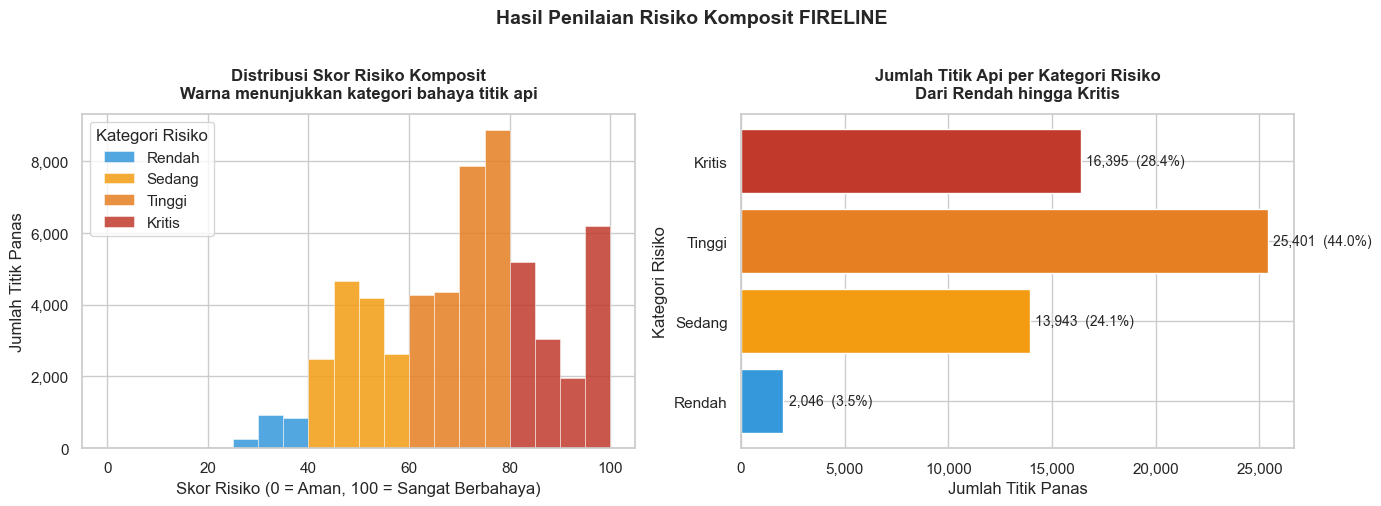

In [12]:
print("\n[5.3] Visualisasi distribusi skor risiko komposit")

cat_colors = {'Rendah': '#3498DB', 'Sedang': '#F39C12', 'Tinggi': '#E67E22', 'Kritis': '#C0392B'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bins = np.arange(0, 105, 5)
for cat, color in cat_colors.items():
    subset = df_master[df_master['risk_category'] == cat]['risk_score']
    ax.hist(subset, bins=bins, color=color, alpha=0.85, edgecolor='white', linewidth=0.4, label=cat)

ax.set_title('Distribusi Skor Risiko Komposit\nWarna menunjukkan kategori bahaya titik api', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Skor Risiko (0 = Aman, 100 = Sangat Berbahaya)')
ax.set_ylabel('Jumlah Titik Panas')
ax.legend(title='Kategori Risiko')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax = axes[1]
cat_order = ['Rendah', 'Sedang', 'Tinggi', 'Kritis']
cat_counts = df_master['risk_category'].value_counts().reindex(cat_order, fill_value=0)
cat_pct = cat_counts / cat_counts.sum() * 100

bars = ax.barh(cat_order, cat_counts.values,
               color=[cat_colors[c] for c in cat_order], edgecolor='white')
for i, (v, pct) in enumerate(zip(cat_counts.values, cat_pct.values)):
    ax.text(v + max(cat_counts)*0.01, i, f"{v:,}  ({pct:.1f}%)", va='center', fontsize=10)

ax.set_title('Jumlah Titik Api per Kategori Risiko\nDari Rendah hingga Kritis', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Jumlah Titik Panas')
ax.set_ylabel('Kategori Risiko')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Hasil Penilaian Risiko Komposit FIRELINE', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{fig_dir}/E1_distribusi_skor_risiko.png', dpi=150, bbox_inches='tight')
plt.show()

[5.3b] Visualisasi skor risiko per provinsi


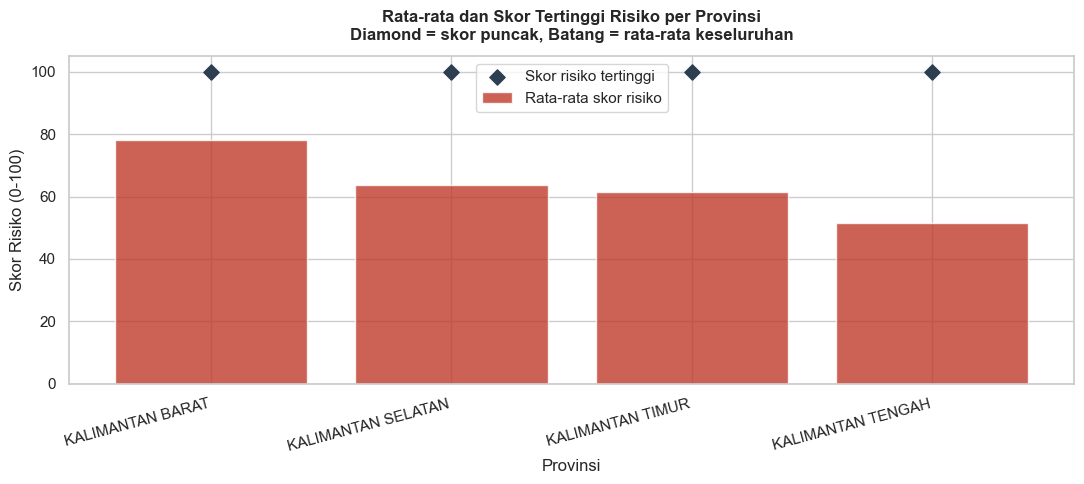

In [13]:
print("[5.3b] Visualisasi skor risiko per provinsi")

fig, ax = plt.subplots(figsize=(11, 5))
prov_risk = df_master.groupby('province_name')['risk_score'].agg(['mean', 'max', 'count']).sort_values('mean', ascending=False)

x = range(len(prov_risk))
bars = ax.bar(x, prov_risk['mean'], color=PALETTE_RED, alpha=0.8, label='Rata-rata skor risiko', edgecolor='white')
ax.scatter(x, prov_risk['max'], color='#2C3E50', zorder=5, s=60, label='Skor risiko tertinggi', marker='D')

ax.set_xticks(x)
ax.set_xticklabels(prov_risk.index, rotation=15, ha='right')
ax.set_title('Rata-rata dan Skor Tertinggi Risiko per Provinsi\nDiamond = skor puncak, Batang = rata-rata keseluruhan', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Provinsi')
ax.set_ylabel('Skor Risiko (0-100)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{fig_dir}/E2_risiko_provinsi.png', dpi=150, bbox_inches='tight')
plt.show()

## Pengarsipan Data Matang Hasil Analisis
Data final yang sudah memuat skor risiko dan kategori ancaman disimpan dan siap digunakan pada dashboard.

In [14]:
print("\n[5.4] Menyimpan data matang berpredikat prioritas ancaman")
df_master.to_csv('../data/processed/hotspot_scored_final.csv', index=False)
print("     Data berhasil disimpan ke ../data/processed/hotspot_scored_final.csv")


[5.4] Menyimpan data matang berpredikat prioritas ancaman
     Data berhasil disimpan ke ../data/processed/hotspot_scored_final.csv


## Menjawab 4 Pertanyaan Utama Proyek
Berdasarkan arahan awal proyek, analisis ini bertujuan untuk menjawab 4 pertanyaan operasional utama.
Berikut adalah ekstraksi jawaban langsung dari model skor yang telah dihitung.

In [15]:
print("\n[5.5] Menyusun laporan jawaban 4 pertanyaan utama")
top_urgent = df_master.sort_values(by='risk_score', ascending=False).head(5)
top_vuln = df_master.sort_values(by=['exposure_score', 'population'], ascending=[False, False]).head(5)
top_verify = df_master.sort_values(by='verification_priority', ascending=False).head(5)

with open('../outputs/core_questions_answers.md', 'w', encoding='utf-8') as f:
    f.write("# Jawaban 4 Pertanyaan Operasional Utama FIRELINE\n\n")

    f.write("## 1. Area mana yang paling mendesak untuk diselamatkan saat ini?\n")
    f.write("Berdasarkan Skor Risiko Komposit tertinggi (gabungan intensitas, paparan, dan populasi):\n")
    for i, row in top_urgent.iterrows():
        f.write(f"- Titik di {row.get('province_name', 'Tidak diketahui')} (Lat: {row['latitude']:.4f}, Lon: {row['longitude']:.4f}) dengan Skor Kritis: **{row['risk_score']}** (FRP: {row['frp']} MW)\n")

    f.write("\n## 2. Populasi mana yang paling rentan?\n")
    f.write("Berdasarkan kedekatan titik api ke lokasi Sekolah dan kepadatan populasi provinsi:\n")
    for i, row in top_vuln.iterrows():
        f.write(f"- Area {row.get('province_name', 'Tidak diketahui')} (Lat: {row['latitude']:.4f}) memiliki kebakaran berjarak hanya **{row.get('dist_nearest_school_km', 100):.2f} km** dari sekolah terdekat.\n")

    f.write("\n## 3. Laporan mana yang harus diverifikasi terlebih dahulu?\n")
    f.write("Berdasarkan Prioritas Verifikasi (Skor Risiko tertimbang oleh kepercayaan satelit):\n")
    for i, row in top_verify.iterrows():
        f.write(f"- Titik di {row.get('province_name', 'Tidak diketahui')} (Kepercayaan: {row.get('confidence', 'n')}) dengan Skor Prioritas: **{row['verification_priority']}**\n")

    f.write("\n## 4. Respons apa yang harus diprioritaskan terlebih dahulu?\n")
    kritis_count = (df_master['risk_category'] == 'Kritis').sum()
    near_school = ((df_master['risk_score'] >= 80) & (df_master['dist_nearest_school_km'] <= 5)).sum()
    f.write(f"- Total titik dengan kategori Kritis (skor lebih dari 80): **{kritis_count:,}** titik.\n")
    f.write(f"- Titik Kritis yang sekaligus berada dalam 5 km dari sekolah: **{near_school:,}** titik.\n")
    f.write("- Tim respons udara harus difokuskan pada titik berintensitas ekstrem (FRP sangat tinggi) yang prioritas verifikasinya tinggi namun sulit dijangkau lewat darat.\n")

print("     Laporan berhasil disimpan di ../outputs/core_questions_answers.md")

elapsed = time.time() - start_time
print(f"FASE 5 SELESAI DALAM {elapsed:.1f} DETIK")


[5.5] Menyusun laporan jawaban 4 pertanyaan utama
     Laporan berhasil disimpan di ../outputs/core_questions_answers.md
FASE 5 SELESAI DALAM 2.4 DETIK
